In [28]:
from tic.data import load_region, load_xenium_dataset

UPMC_Region_1 = load_region()
Xenium_Kieney_cancer = load_xenium_dataset(name='xenium_kidney_cancer')

2025-06-05 23:26:04,433 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-05 23:26:04,433 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-05 23:26:08,068 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-05 23:26:08,068 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-05 23:26:08,069 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-05 23:26:08,467 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-06-05 23:26:08,487 | INFO     | tic.data.codex.loader | Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-06-05 23:26:08,488 | INFO     | tic.data.xenium

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from anndata import AnnData


def plot_cell_scatter(
    adata: AnnData,
    cell_type_key: str = "cell_type",
    spatial_key: str = "spatial",
    figsize: tuple = (6, 6),
    normalize_coords: bool = True,
    title: str = "Cell Scatter Plot by Type",
    save_path: str = None,
    marker_size: float = 6.0
) -> None:
    """
    Plot 2D scatter of cell coordinates, colored by cell type.

    Parameters
    ----------
    adata : AnnData
        AnnData object with cell coordinates in `obsm[spatial_key]`.
    cell_type_key : str
        Key in `obs` for cell type annotations.
    spatial_key : str
        Key in `obsm` for spatial coordinates (2D).
    figsize : tuple
        Size of the figure.
    normalize_coords : bool
        Whether to normalize coordinates to [0, 1].
    title : str
        Title of the plot.
    save_path : str or None
        If provided, save the plot to this path.
    marker_size : float
        Size of each point.
    """
    coords = adata.obsm[spatial_key]
    if normalize_coords:
        coords = MinMaxScaler().fit_transform(coords)

    cell_types = adata.obs[cell_type_key].astype(str).values
    unique_types = np.unique(cell_types)
    color_map = {ct: plt.cm.tab20(i % 20) for i, ct in enumerate(unique_types)}
    cell_colors = np.array([color_map[ct] for ct in cell_types])

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:, 0], coords[:, 1], c=cell_colors, s=marker_size, edgecolor='k', linewidth=0.1)

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for ct in unique_types:
        ax.plot([], [], color=color_map[ct], label=ct, marker='s', linestyle='')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-small', frameon=False)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

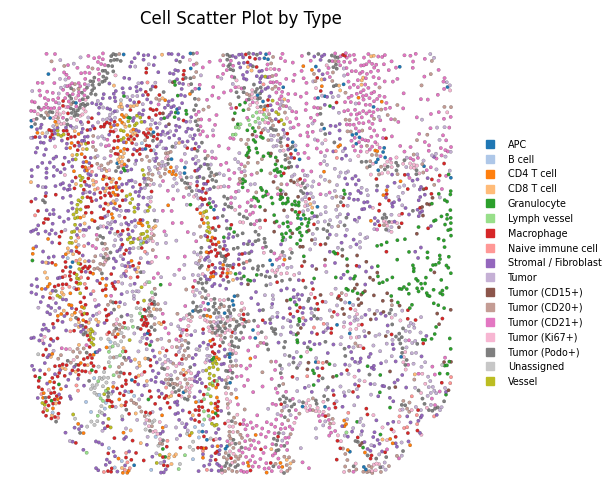

In [30]:
plot_cell_scatter(UPMC_Region_1)